In [1]:
from google.colab import files

uploaded = files.upload()

Saving netflix_titles.csv to netflix_titles.csv


In [2]:
# baca dataset
import pandas as pd

df = pd.read_csv('netflix_titles.csv')

df.head()

,show_id,type,title,director,cast,country,date_added,release_year,rating,duration,listed_in,description
0,s1,Movie,Dick Johnson Is Dead,Kirsten Johnson,NaN,United States,"September 25, 2021",2020,PG-13,90 min,Documentaries,"As her father nears the end of his life, filmm..."
1,s2,TV Show,Blood & Water,NaN,"Ama Qamata, Khosi Ngema, Gail Mabalane, Thaban...",South Africa,"September 24, 2021",2021,TV-MA,2 Seasons,"International TV Shows, TV Dramas, TV Mysteries","After crossing paths at a party, a Cape Town t..."
2,s3,TV Show,Ganglands,Julien Leclercq,"Sami Bouajila, Tracy Gotoas, Samuel Jouy, Nabi...",NaN,"September 24, 2021",2021,TV-MA,1 Season,"Crime TV Shows, International TV Shows, TV Act...",To protect his family from a powerful drug lor...
3,s4,TV Show,Jailbirds New Orleans,NaN,NaN,NaN,"September 24, 2021",2021,TV-MA,1 Season,"Docuseries, Reality TV","Feuds, flirtations and toilet talk go down amo..."
4,s5,TV Show,Kota Factory,NaN,"Mayur More, Jitendra Kumar, Ranjan Raj, Alam K...",India,"September 24, 2021",2021,TV-MA,2 Seasons,"International TV Shows, Romantic TV Shows, TV ...",In a city of coaching centers known to train I...


In [4]:
# cek isi dataset
print("Jumlah baris dan kolom:")
print(df.shape)

Jumlah baris dan kolom:
(8807, 12)


In [5]:
print("\nNama kolom:")
print(df.columns)


Nama kolom:
Index(['show_id', 'type', 'title', 'director', 'cast', 'country', 'date_added',
       'release_year', 'rating', 'duration', 'listed_in', 'description'],
      dtype='object')


In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8807 entries, 0 to 8806
Data columns (total 12 columns):
 #   Column        Non-Null Count  Dtype 
---  ------        --------------  ----- 
 0   show_id       8807 non-null   object
 1   type          8807 non-null   object
 2   title         8807 non-null   object
 3   director      6173 non-null   object
 4   cast          7982 non-null   object
 5   country       7976 non-null   object
 6   date_added    8797 non-null   object
 7   release_year  8807 non-null   int64 
 8   rating        8803 non-null   object
 9   duration      8804 non-null   object
 10  listed_in     8807 non-null   object
 11  description   8807 non-null   object
dtypes: int64(1), object(11)
memory usage: 825.8+ KB


In [7]:
# cek missing value
df.isnull().sum()

,0
show_id,0
type,0
title,0
director,2634
cast,825
country,831
date_added,10
release_year,0
rating,4
duration,3


In [8]:
# tangani missing value
df_clean = df.copy()

df_clean['director'] = df_clean['director'].fillna('Unknown')
df_clean['cast'] = df_clean['cast'].fillna('Unknown')
df_clean['country'] = df_clean['country'].fillna('Unknown')
df_clean['rating'] = df_clean['rating'].fillna('Not Rated')

df_clean.isnull().sum()

,0
show_id,0
type,0
title,0
director,0
cast,0
country,0
date_added,10
release_year,0
rating,0
duration,3


In [9]:
# tangani yang masih ada
df_clean = df_clean.dropna(subset=['date_added', 'duration'])
df_clean.isnull().sum()

,0
show_id,0
type,0
title,0
director,0
cast,0
country,0
date_added,0
release_year,0
rating,0
duration,0


Analisis

In [11]:
# Movie vs TV Show
df_clean['type'].value_counts()

,count
type,
Movie,6128
TV Show,2666


In [12]:
# Top 10 Genre
genres = df_clean['listed_in'].str.split(', ').explode()

genres.value_counts().head(10)

,count
listed_in,
International Movies,2752
Dramas,2427
Comedies,1674
International TV Shows,1350
Documentaries,869
Action & Adventure,859
TV Dramas,762
Independent Movies,756
Children & Family Movies,641


In [13]:
# Top 10 Country
df_clean['country'].value_counts().head(10)

,count
country,
United States,2809
India,972
Unknown,830
United Kingdom,418
Japan,244
South Korea,199
Canada,181
Spain,145
France,124


In [14]:
# Top Rating
df_clean['rating'].value_counts().head(10)

,count
rating,
TV-MA,3205
TV-14,2157
TV-PG,861
R,799
PG-13,490
TV-Y7,333
TV-Y,306
PG,287
TV-G,220


Visualiasi

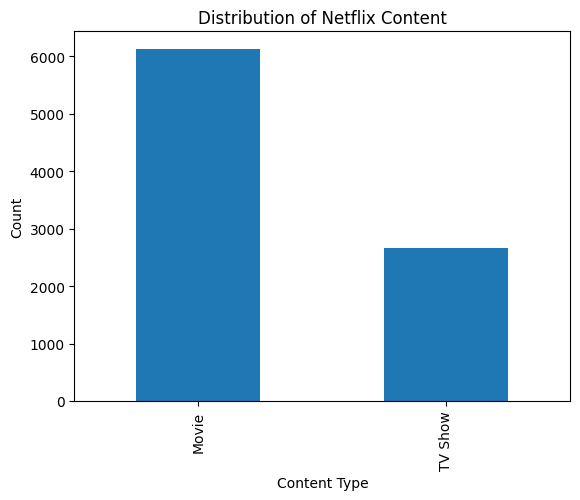

In [15]:
# Movie vs TV Show
import matplotlib.pyplot as plt

df_clean['type'].value_counts().plot(kind='bar')

plt.title('Distribution of Netflix Content')
plt.xlabel('Content Type')
plt.ylabel('Count')

plt.show()

In [16]:
plt.savefig('movie_vs_tvshow.png', bbox_inches='tight')

<Figure size 640x480 with 0 Axes>

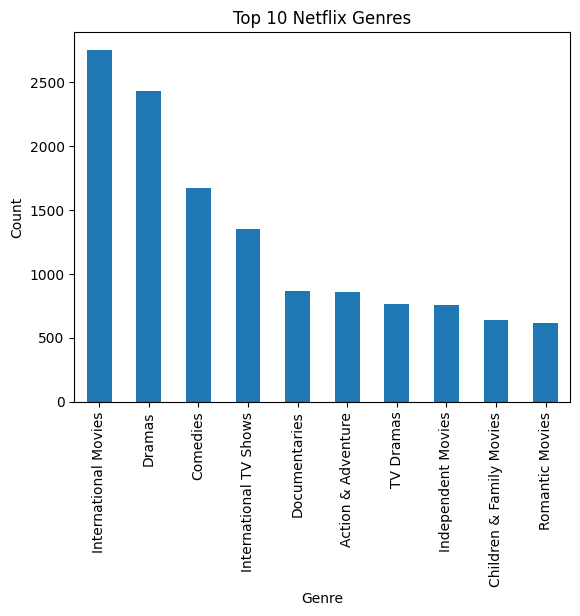

In [17]:
# Top 10 Genre
genres.value_counts().head(10).plot(kind='bar')

plt.title('Top 10 Netflix Genres')
plt.xlabel('Genre')
plt.ylabel('Count')

plt.show()

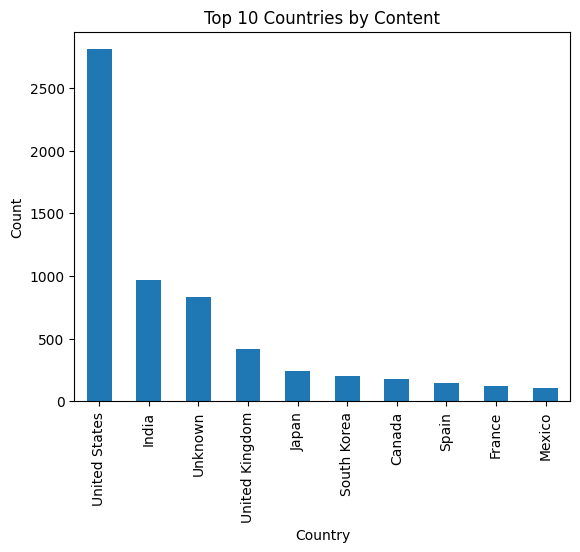

In [18]:
# Top 10 Countries
df_clean['country'].value_counts().head(10).plot(kind='bar')

plt.title('Top 10 Countries by Content')
plt.xlabel('Country')
plt.ylabel('Count')

plt.show()

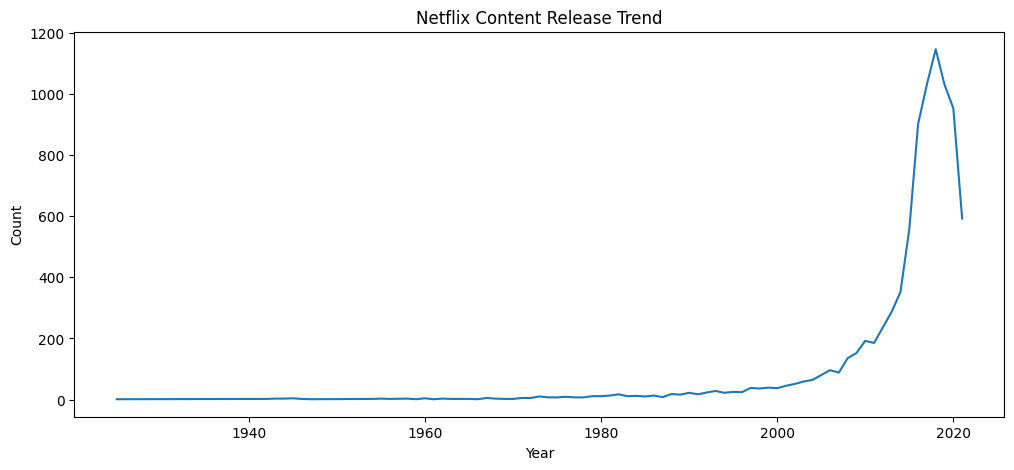

In [19]:
# Content Release Trend
df_clean['release_year'].value_counts().sort_index().plot(figsize=(12,5))

plt.title('Netflix Content Release Trend')
plt.xlabel('Year')
plt.ylabel('Count')

plt.show()

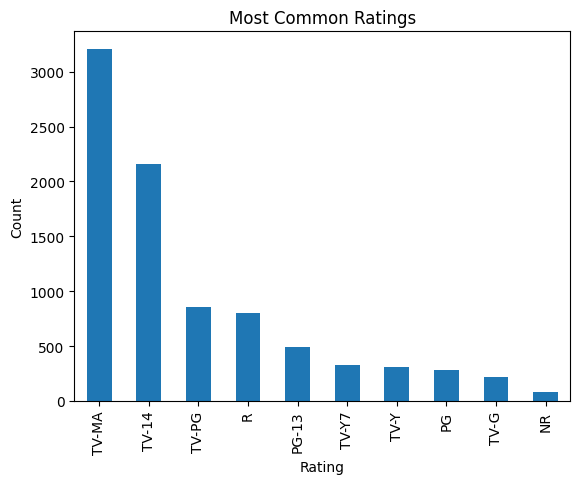

In [21]:
# Top Ratings
df_clean['rating'].value_counts().head(10).plot(kind='bar')

plt.title('Most Common Ratings')
plt.xlabel('Rating')
plt.ylabel('Count')

plt.show()

# Netflix Content Analysis

## Objective
Analyze Netflix content distribution by type, genre, country, release year, and rating.

## Data Cleaning
- Filled missing values in director, cast, country, and rating.
- Removed records with missing date_added and duration.

## Exploratory Data Analysis
- Content Type Distribution
- Top Genres
- Top Countries
- Release Trend
- Rating Distribution